<a href="https://colab.research.google.com/github/Doufoungognon/portfolio/blob/main/Transfer_Learning_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets, models, transforms

#### Загрузка модели из torchvision

In [ ]:
# например, модель resnet-18
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 44.3MB/s]


In [ ]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Чтобы использовать предобученную сеть resnet18 наиболее эффективно, нужно все изображения, которые мы подаем ей на вход, предобрабатывать определенным образом. Для всех сетей семейства resnet есть свои фиксированные преобразования:

In [ ]:
resnet_transforms = transforms.Compose([
        transforms.Resize(256), # размер каждого изображение будет приведен к 256*256
        transforms.CenterCrop(224), # вырезает центральный регион изображения размером 224×224 пикселя
        transforms.ToTensor(), # изображение из массива переводится в формат torch.Tensor тензор (каналы, высота, ширина)
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # значения пикселей картинки нормализуются
    ])



#### Пример:
Загрузим изображение и протестируем предобученную нейронную сеть

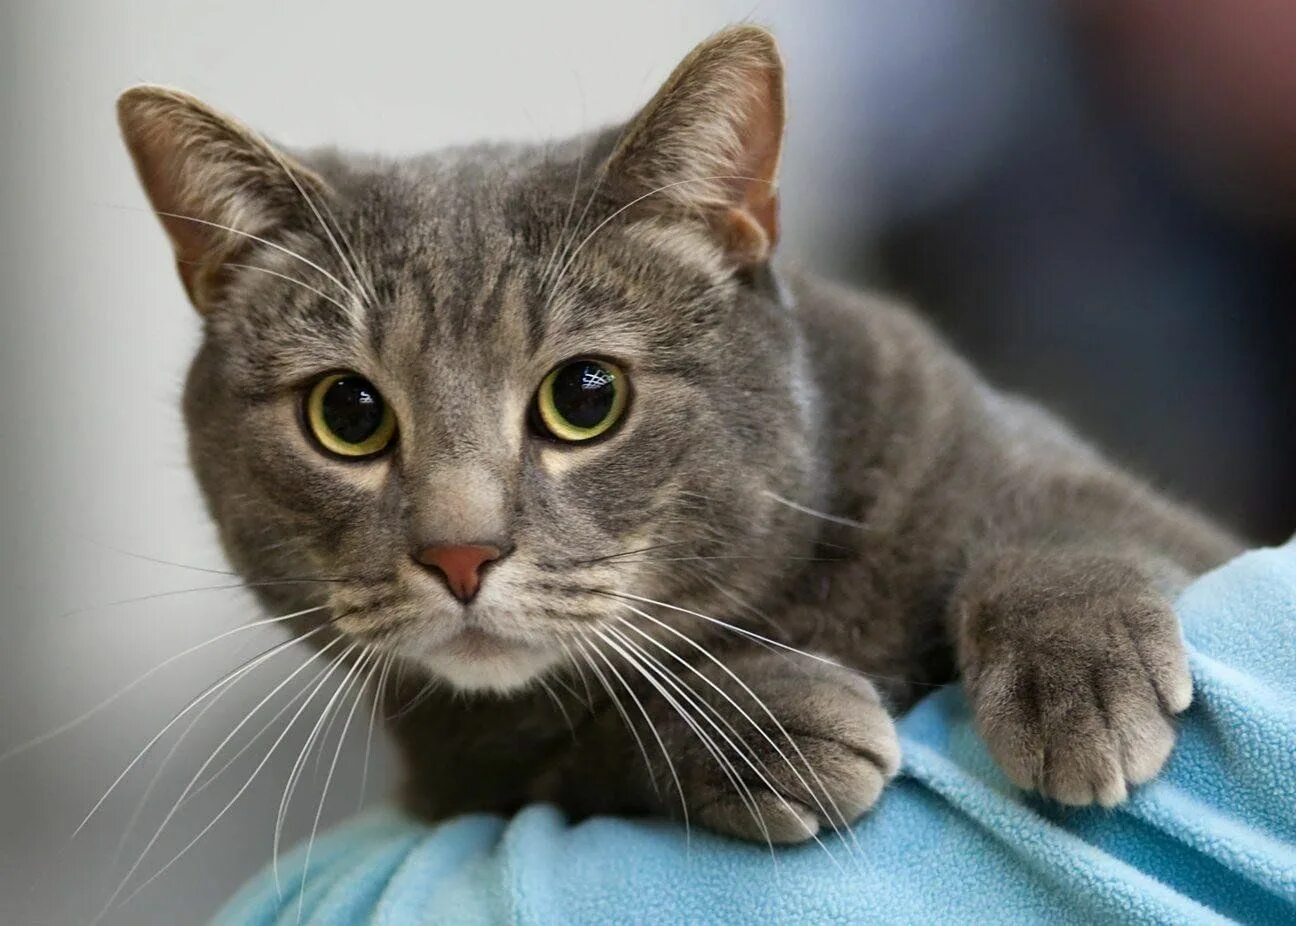

In [ ]:
from PIL import Image

image = Image.open('cat.jpg')
image

In [ ]:
np.array(image).shape

(926, 1296, 3)

Применим трансформации:

In [ ]:
image_transformed = resnet_transforms(image)
print(image_transformed.shape)

torch.Size([3, 224, 224])


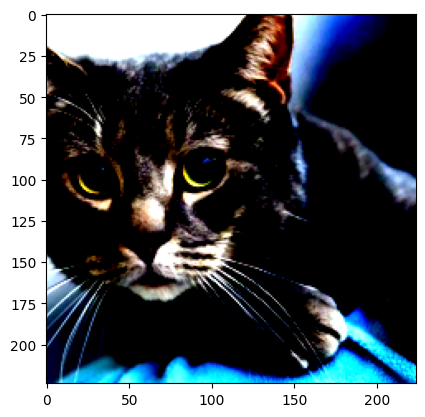

In [ ]:
plt.imshow(image_transformed.permute(1,2,0).data.cpu().numpy())

Подадим изображение на вход сети и получим ответ:

In [ ]:
model.eval()

with torch.no_grad():
    # image_transformed -> [image_transformed]
    model_output = model(image_transformed.reshape((1, 3, 224, 224)))

model_output

tensor([[ 8.0971e-01, -1.4912e+00, -6.4672e-01, -1.0461e+00,  2.4848e-01,
         -1.3163e+00, -8.3914e-01, -3.2896e+00, -3.7690e+00, -3.3241e+00,
         -2.9535e+00, -3.4631e+00, -5.7307e-01, -2.5486e+00, -3.8145e+00,
          8.7631e-01, -1.0617e+00, -1.7105e+00, -2.6167e+00, -3.7601e+00,
         -4.7130e-01, -5.1211e-01, -5.4779e-01, -3.2094e+00,  6.7510e-01,
         -2.9361e+00, -7.3595e-01, -1.1566e+00, -1.6441e+00, -1.0433e+00,
          7.0048e-01, -2.4422e+00, -2.7121e+00, -4.9175e+00, -1.3523e+00,
         -1.3405e+00, -1.2886e+00, -2.0513e+00,  5.4970e-01,  2.0739e+00,
         -1.4071e+00,  5.9828e-01, -3.7772e+00, -1.2486e+00, -2.1957e+00,
         -2.8263e+00,  4.7241e-01,  6.2357e-01, -4.8672e-01, -3.2081e+00,
         -3.2080e+00,  9.5715e-01, -1.2458e+00, -1.8410e+00, -1.5744e+00,
         -5.3204e-01, -2.7229e+00, -3.0603e+00, -1.5517e+00,  5.2894e-01,
         -4.6888e-01, -1.6868e+00, -2.0073e+00, -2.0306e+00,  6.2111e-01,
         -2.0137e+00,  1.2612e+00,  4.

In [ ]:
np.argmax(model_output.data.cpu().numpy())

np.int64(281)

## Transfer Learning

Суть **трансферного обучения** в том, чтобы взять модель, успешно решающую одну задачу, и использовать её опыт как базу для решения другой, но родственной задачи. Такой подход избавляет от необходимости обучать ИИ с нуля — достаточно перенести уже имеющиеся знания.


Принцип работы включает два основных этапа:


*   ***Предварительное обучение (pre-training)***. Модель обучается на крупномасштабном эталонном наборе данных (например, ImageNet), чтобы изучить общие визуальные представления, паттерны и признаки.
*   ***Адаптация к новой задаче (fine-tuning)***.
Предварительно обученная модель дообучается на специализированном наборе данных путём «замораживания» ранних слоёв и дообучения только конечных слоёв (для свёрточных архитектур) или дообучение LLM (на меньшем наборе данных, созданном специально для этой задачи) с помощью адаптеров.

In [ ]:
# скачаем zip архив с данными
! pip install wldhx.yadisk-direct
! curl -L $(yadisk-direct https://disk.yandex.com/d/eS6LL7bLmrlO7w) -o dogs.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  218M  100  218M    0     0  16.1M      0  0:00:13  0:00:13 --:--:-- 20.8M


In [ ]:
# распакуем архив в папку ./dogs
! unzip -qq dogs.zip

In [ ]:
resnet_transforms = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomPerspective(distortion_scale=0.6, p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

In [ ]:
train_data = datasets.ImageFolder('./dogs/train', transform=resnet_transforms)
val_data = datasets.ImageFolder('./dogs/valid', transform=resnet_transforms)
test_data = datasets.ImageFolder('./dogs/test', transform=resnet_transforms)

In [ ]:
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)

#### Замена последнего слоя сети

Загрузим модель, которую будем дообучать:

In [ ]:
model = models.resnet18(pretrained=True)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
model.fc

Linear(in_features=512, out_features=1000, bias=True)

Заменим последний слой сети на новый, содержащий 70 нейронов (так как у нас 70 классов в датасете):

In [ ]:
model.fc = nn.Linear(512, 70)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#### Заморозка слоев

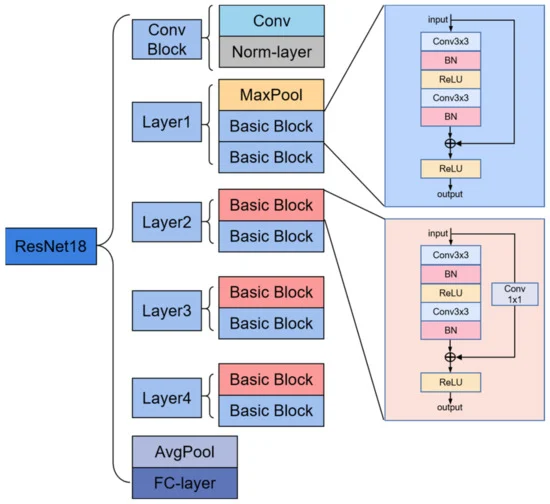

In [ ]:
# model.children() выдает список сабмодулей нейросети
# в нашем случае это блоки resnet
len(list(model.children()))

10

Заморозим все сверточные слои:

In [ ]:
# проходимся по блокам нейросети
for i, layer in enumerate(model.children()):

  # заморозим первые девять блоков
  if i < 9:
    # проходимся по всем весам (параметрам) блока
    for param in layer.parameters():
      # замораживаем парметр
      param.requires_grad = False

Соберем НС:

In [ ]:
def create_model(model, num_freeze_layers, num_out_classes):
    # замена последнего слоя сети
    model.fc = nn.Sequential(nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, num_out_classes))

    # заморозка слоев
    for i, layer in enumerate(model.children()):
        if i < num_freeze_layers:
            for param in layer.parameters():
                param.requires_grad = False

    return model

In [ ]:
model = create_model(models.resnet18(pretrained=True), 9, 70)

#### Обучение сети

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
def evaluate(model, dataloader, loss_fn):
    model.eval()
    losses = []

    num_correct = 0
    num_elements = 0

    for i, batch in enumerate(dataloader):

        # получаем текущий батч
        X_batch, y_batch = batch
        num_elements += len(y_batch)

        with torch.no_grad():
            # получаем ответы сети на картинки батча
            logits = model(X_batch.to(device))

            # вычисляем лосс на текущем батче
            loss = loss_fn(logits, y_batch.to(device))
            losses.append(loss.item())

            # вычисляем ответы сети как номера классов
            y_pred = torch.argmax(logits, dim=1)

            # вычисляем количество правильных ответов сети в текущем батче
            num_correct += torch.sum(y_pred.cpu() == y_batch)

    # вычисляем итоговую долю правильных ответов
    accuracy = num_correct / num_elements

    return accuracy.numpy(), np.mean(losses)

def train(model, loss_fn, optimizer, n_epoch=3):

    # цикл обучения сети
    for epoch in range(n_epoch):

        print("Epoch:", epoch+1)

        model.train(True)

        running_losses = []
        running_accuracies = []
        for i, batch in enumerate(train_loader):
            # получаем текущий батч
            X_batch, y_batch = batch

            # forward pass (получение ответов на батч изображений)
            logits = model(X_batch.to(device))

            # вычисление лосса от выданных сетью ответов и правильных ответов на батч
            loss = loss_fn(logits, y_batch.to(device))
            running_losses.append(loss.item())

            loss.backward() # вычисление градиентов
            optimizer.step() # обновление весов сети
            optimizer.zero_grad() # обнуляем веса

            # вычислим accuracy на текущем train батче
            model_answers = torch.argmax(logits, dim=1)
            train_accuracy = torch.sum(y_batch == model_answers.cpu()) / len(y_batch)
            running_accuracies.append(train_accuracy)

            # Логирование результатов
            if (i+1) % 50 == 0:
                print("Средние train лосс и accuracy на последних 50 итерациях:",
                      np.mean(running_losses), np.mean(running_accuracies), end='\n')

        # после каждой эпохи получаем метрику качества на валидационной выборке
        model.train(False)

        val_accuracy, val_loss = evaluate(model, val_loader, loss_fn=loss_fn)
        print("Эпоха {}/{}: val лосс и accuracy:".format(epoch+1, n_epoch,),
                      val_loss, val_accuracy, end='\n')

    return model

In [ ]:
# снова объявим модель
model = create_model(models.resnet18(pretrained=True), 9, 70)
model = model.to(device)

# выбираем функцию потерь
loss_fn = torch.nn.CrossEntropyLoss()

learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
# запустим обучение модели
model = train(model, loss_fn, optimizer, n_epoch=3)

Epoch: 1
Средние train лосс и accuracy на последних 50 итерациях: 3.185876250267029 0.2859375
Средние train лосс и accuracy на последних 50 итерациях: 2.3960297667980193 0.43171874
Эпоха 1/3: val лосс и accuracy: 1.136378439989957 0.73571426
Epoch: 2
Средние train лосс и accuracy на последних 50 итерациях: 1.032095606327057 0.6984375
Средние train лосс и accuracy на последних 50 итерациях: 1.015692937374115 0.7028125
Эпоха 2/3: val лосс и accuracy: 0.9007178490812128 0.7871429
Epoch: 3
Средние train лосс и accuracy на последних 50 итерациях: 0.8573037958145142 0.7421875
Средние train лосс и accuracy на последних 50 итерациях: 0.8658151027560234 0.736875
Эпоха 3/3: val лосс и accuracy: 0.8805171982808546 0.79571426


In [ ]:
learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
model = train(model, loss_fn, optimizer, n_epoch=1)

Epoch: 1
Средние train лосс и accuracy на последних 50 итерациях: 0.7184235274791717 0.7875
Средние train лосс и accuracy на последних 50 итерациях: 0.6809283182024956 0.7953125
Эпоха 1/1: val лосс и accuracy: 0.7711237411607396 0.8442857


#### Получение метрики качества на тестовой выборке

In [ ]:
test_accuracy, _ = evaluate(model, test_loader, loss_fn)
print('Accuracy на тесте', test_accuracy)

Accuracy на тесте 0.87


In [ ]:
model = models.resnet18(pretrained=False)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
# снова объявим модель
model = model.to(device)

# выбираем функцию потерь
loss_fn = torch.nn.CrossEntropyLoss()

# выбираем алгоритм оптимизации и learning_rate.

learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
model = train(model, loss_fn, optimizer, n_epoch=1)

Epoch: 1
Средние train лосс и accuracy на последних 50 итерациях: 4.294160833358765 0.04625
Средние train лосс и accuracy на последних 50 итерациях: 4.0617259192466735 0.056875
Эпоха 1/1: val лосс и accuracy: 4.1988186619498515 0.055714287


In [ ]:
model = train(model, loss_fn, optimizer, n_epoch=2)

Epoch: 1
Средние train лосс и accuracy на последних 50 итерациях: 3.6347822761535644 0.0928125
Средние train лосс и accuracy на последних 50 итерациях: 3.559594900608063 0.1096875
Эпоха 1/2: val лосс и accuracy: 3.4787356853485107 0.12857144
Epoch: 2
Средние train лосс и accuracy на последних 50 итерациях: 3.3489626121520994 0.16125
Средние train лосс и accuracy на последних 50 итерациях: 3.3138097739219665 0.161875
Эпоха 2/2: val лосс и accuracy: 6.819068041714755 0.02


In [ ]:
test_accuracy, _ = evaluate(model, test_loader, loss_fn)
print('Accuracy на тесте', test_accuracy)

Accuracy на тесте 0.028571429
